In [7]:
import os, yaml, sys
import numpy as np
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
from general_utils.utils import BrainAreas, dRSA, load_img_natraster, print_wise, TimeSeries
from general_utils.dRSA import across_areas_dRSA
from general_utils.II import InformationImbalance, compare_similarity_metrics

In [8]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    monkey_name: str = 'three0' 
    date: str = '250313'
    brain_area: str = 'AIT'
    new_fs: int = 100 # Hz
    k: int = 1
    RDM_metric = 'cosine'
cfg = Cfg()


In [3]:
import h5py
from general_utils.utils import TimeSeries, BrainAreas
def load_img_natraster_three0(paths: dict[str: str], monkey_name, date, ev_od, new_fs=None, brain_area=None):
    rasters_path = f"{paths['livingstone_lab']}/tiziano/data/{monkey_name}_natraster{ev_od}{date}.mat"
    with h5py.File(rasters_path, "r") as f:
        rasters = f[f"natraster{ev_od}"][:]  
        
    rasters = rasters.astype(np.float32)
    rasters = rasters.transpose(2, 1, 0)
    rasters = TimeSeries(rasters, 1000)
    if brain_area is not None:
            brain_areas_obj = BrainAreas(monkey_name)
            rasters = brain_areas_obj.slice_brain_area(rasters, brain_area)
    # end if brain_area is not None:
    if new_fs is not None:
        rasters.resample(new_fs)
    # if new_fs is not None:
    return rasters
# EOF

In [6]:
raster_three0_od = load_img_natraster_three0(paths, cfg.monkey_name, cfg.date, 'Od', new_fs=cfg.new_fs)
raster_three0_ev = load_img_natraster_three0(paths, cfg.monkey_name, cfg.date, 'Ev', new_fs=cfg.new_fs)

In [ ]:
plt.imshow(raster_three0_ev.get_array()[0,])

In [15]:
raster_three0_od.get_array().shape

(383, 30, 776)

In [9]:
drsa_obj = dRSA(cfg.RDM_metric)

In [10]:
drsa_obj.compute_both_RDM_timeseries(raster_three0_od, raster_three0_ev)

In [12]:
dRSA_mat = drsa_obj.compute_dRSA()

Text(0.5, 1.0, 'dRSA self consistency over the diagonals')

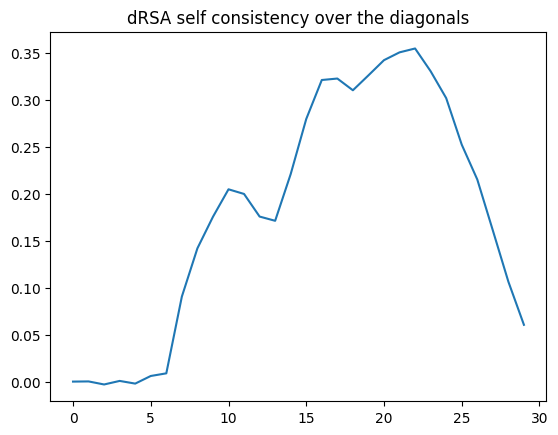

In [16]:
plt.plot(np.diag(dRSA_mat))
plt.title("dRSA self consistency over the diagonals")

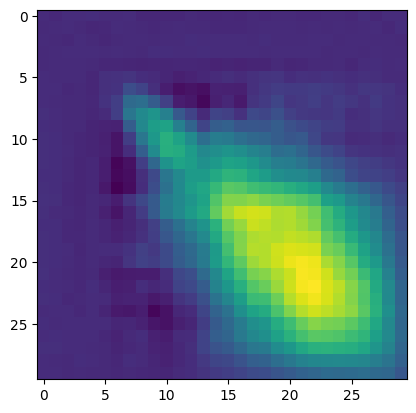

In [17]:
plt.imshow(dRSA_mat)